# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, GRIS, REJILLA = "#13294B", "#5F6472", "#D3D8E0"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

df = pd.read_csv("spotify_songs.csv")

# La duración viene en milisegundos: la pasamos a minutos, que sí se puede interpretar.
df["duration_min"] = df["duration_ms"] / 60000

# Las 10 variables de audio con las que vamos a trabajar todo el problem set.
audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

print("Filas y columnas:", df.shape)

Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [57]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,3.245900
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2.710000
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2.943600
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2.818217
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,3.150867


In [58]:
# b) Resumen estadístico
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622,3.763330
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182,0.997233
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,0.066667
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000,3.130317
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000,3.600000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000,4.226417
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000,8.630167


In [59]:
# c) Canciones por género
df["playlist_genre"].value_counts().sort_values(ascending=False)

playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

In [60]:
# d) Valores faltantes
faltan = df.isna().sum()
print("Faltantes por columna:")
print(faltan[faltan > 0].to_string())  

Faltantes por columna:
track_name          5
track_artist        5
track_album_name    5


### 📝 Tu respuesta — Ejercicio 1

**1.** ¿Los seis géneros tienen más o menos la misma cantidad de canciones, o hay alguno
   muy por encima o por debajo? ¿Por qué importa eso antes de comparar promedios entre géneros?

>Se tiene una diferencia de 1000 canciones entre el género con mayor cantidad versus menor cantidad. 

**2.** Mira la fila `min` y la fila `max` de `duration_min` en el `describe()`. ¿Hay algún valor
   que te haga sospechar de un error de captura? Explica en una frase.

>Se tiene que el valor mínimo es de 0.06 minutos. Este valor muy posiblemente se trate de un error de captura ya que 4 segundos corresponde un tiempo demasiado corto para tratarse de una canción, pero no imposible ya que algunos artistas mantienen interludios en sus álbumes. Con respecto al valor máximo, definitivamente se trata de un valor muy probable ya que existe una gran cantidad de canciones que pueden llegar hasta 10 minutos. 

---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

Media:  0.6986192707032559  Mediana:  0.721 Desviación Estándar: 0.18091003391959107
Rango: 0.999825


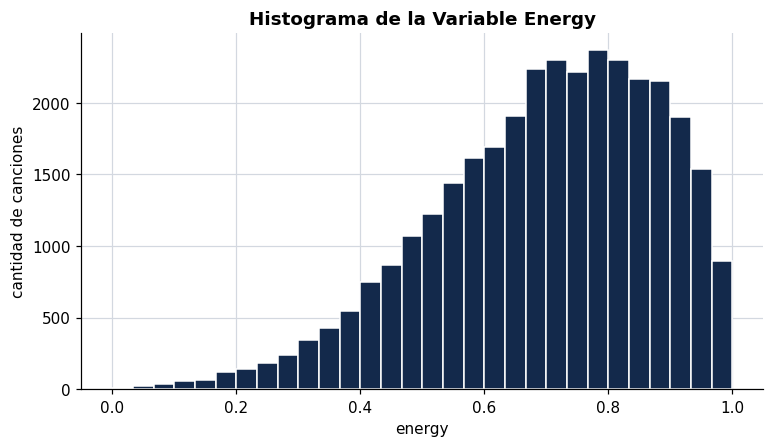

Asimetría o skew: -0.6363298409581123


In [61]:
# a) Media, mediana, desviación estándar y rango de energy
print("Media: ",df["energy"].mean(),
     " Mediana: ",df["energy"].median(), "Desviación Estándar:",df["energy"].std())
rango = df["energy"].max() - df["energy"].min()
print("Rango:", rango)
# b) Histograma
plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("energy")
plt.ylabel("cantidad de canciones")
plt.title ("Histograma de la Variable Energy")
plt.show()
# c) Asimetría
print("Asimetría o skew:",df["energy"].skew())

### 📝 Tu respuesta — Ejercicio 2

**1.** Escribe los cuatro números de (a) en una frase.

>1. Media:  0.6986192707032559  Mediana:  0.721 Desviación Estándar: 0.18091003391959107 Rango: 0.999825

**2.** ¿La media quedó por encima o por debajo de la mediana? ¿Hacia qué lado está la cola?
   ¿Coincide eso con el signo del `skew()` y con lo que ves en el histograma?

>La media  quedó por debajo por la mediana y se mantiene una cola hacia la izquierda.Esto coincide con el signo del skew ya que un signo negativo realmente se muestra en el histograma como una asimetría negativa, lo cual se valida también con la cola hacia la izquierda y con el valor de la media por debajo de la mediana.

---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

                    mean       std
playlist_genre                    
edm             0.802476  0.139415
rock            0.732813  0.194501
latin           0.708312  0.152308
pop             0.701028  0.171084
rap             0.650708  0.170340
r&b             0.590934  0.179407


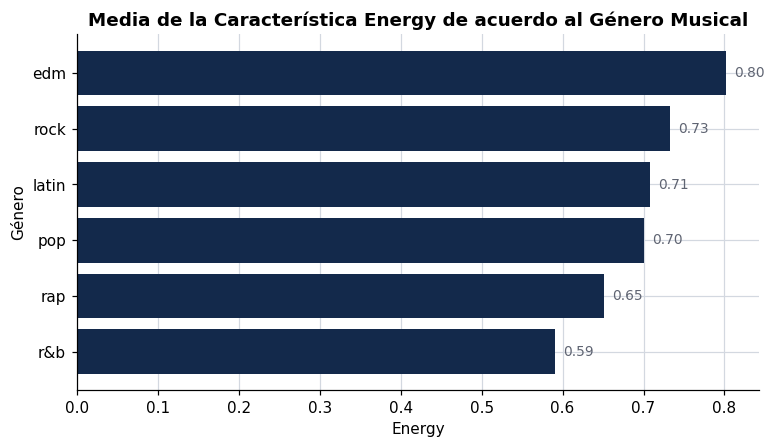

Text(0.5, 0.98, '')

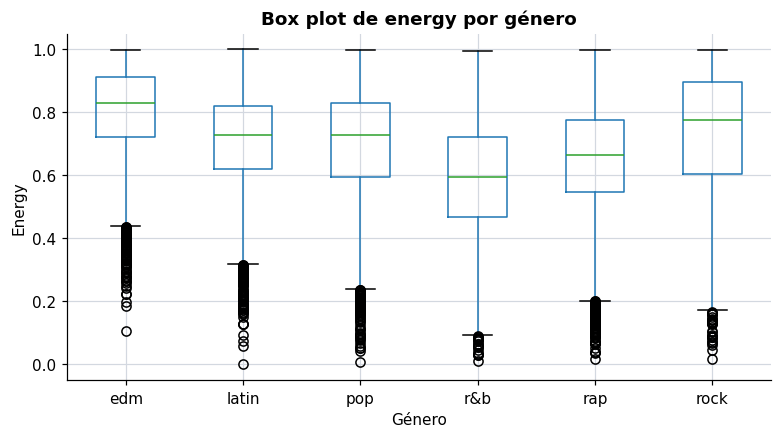

In [62]:
# a) Media y desviación de energy por género
energia_genero = df.groupby("playlist_genre")["energy"].agg(["mean", "std"]).sort_values("mean", ascending=False)
print(energia_genero)

# b) Gráfico de barras horizontales
fig, ax = plt.subplots()
energia_media = energia_genero["mean"].sort_values()
ax.barh(energia_media.index, energia_media.values, color=AZUL)   # barh = barras HORIZONTALES
ax.set_xlabel("Energy")
ax.set_ylabel("Género")          
ax.set_title("Media de la Característica Energy de acuerdo al Género Musical")
for y, v in enumerate(energia_media.values):
    ax.text(v + 0.01, y, f"{v:,.2f}", va="center", color=GRIS, fontsize=9)
plt.show()
# c) Boxplot
df.boxplot(column="energy", by="playlist_genre")
plt.ylabel("Energy")
plt.xlabel("Género")
plt.title("Box plot de energy por género")
plt.suptitle("")   # quita el título automático


### 📝 Tu respuesta — Ejercicio 3

**1.** ¿Cuál es el género **más enérgico** en promedio y cuál el **menos**? Da los dos números.

> En promedio el género edm es el más enérgico con 0.802476. Mientras que el menos es r&b con 0.590934  

**2.** ¿Cuál es el género **más disperso** (mayor desviación estándar)? ¿Es el mismo que el más
   enérgico? ¿Qué significa, en palabras, que un género tenga mucha dispersión en `energy`?

>El género más disperso es el rock. Y esto significa que el valor de la energía que tienen las canciones de este género puede ser muy variado. No es el mismo que el más enérgico, ya que ese es EDM.

**3.** Tapa el código y mira solo tu gráfico de barras. ¿Lo pondrías en un informe sin escribir
   un párrafo explicándolo? Si no, arréglalo antes de seguir.
>Evaluado


---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

total de pares: 45

Más negativo:
acousticness  energy   -0.54
dtype: float64

Más positivo:
energy  loudness    0.677
dtype: float64


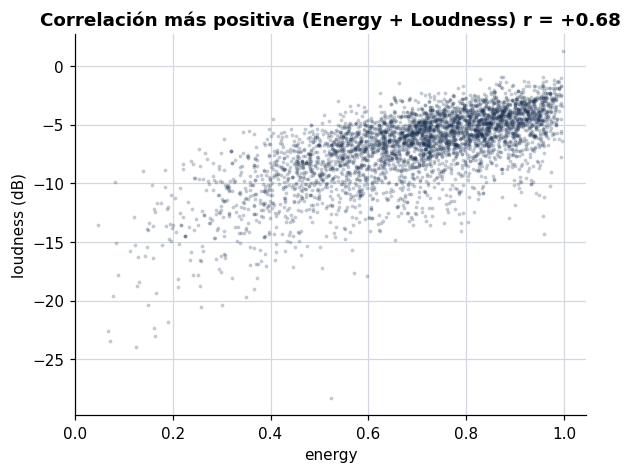

instrumentalness   -0.149872
duration_min       -0.143682
energy             -0.109112
liveness           -0.054584
tempo              -0.005378
speechiness         0.006819
valence             0.033231
loudness            0.057687
danceability        0.064748
acousticness        0.085159
track_popularity    1.000000
Name: track_popularity, dtype: float64

In [63]:
# a) Matriz de correlación
corr = df[audio].corr()

# b) Lista de pares ordenada: el más positivo y el más negativo
pares = corr.unstack()
pares = pares[pares < 0.999] 
pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]
pares = pares.sort_values()
print("total de pares:", len(pares))
print("\nMás negativo:"); print(pares.head(1).round(3))
print("\nMás positivo:"); print(pares.tail(1).round(3))

# c) Diagrama de dispersión del par más positivo
m = df.sample(4000, random_state=1)

plt.figure(figsize=(6, 4.5))
plt.scatter(m["energy"], m["loudness"], s=6, alpha=0.25, color=AZUL, lw=0)
plt.xlabel("energy"); plt.ylabel("loudness (dB)"); plt.title("Correlación más positiva (Energy + Loudness) r = +0.68")
plt.show()
# d) Correlación de cada variable de audio con track_popularity
df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()

### 📝 Tu respuesta — Ejercicio 4

**1.** ¿Cuál es el par con la correlación **positiva** más fuerte y cuál con la **negativa** más
   fuerte? Da los dos valores de r.

> Más positivo: energy - loudness con una correlación de +0.677. Más negativa: energy - acousticness con -0.54.

**2.** Mira tu diagrama de dispersión. La correlación es alta, pero la nube **no** es una línea.
   ¿Qué te dice eso sobre lo que r puede y no puede predecir para **una** canción concreta?

>La correlación solo describe una tendencia general pero no permite predicir con precisión una canción concreta.

**3.** Escribe **una frase de veredicto** sobre el par más positivo: ¿se puede afirmar que una
   variable **causa** a la otra? Antes de responder descarta las tres alternativas que vimos en
   clase: una **variable oculta** que mueva a las dos, la **causa invertida**, o la **coincidencia**.

>No se puede afirmar que la variable de volumen cause que la canción sea considerada más enérgica. La causa de su relación podrían ser dos opciones: la variable oculta, ya que el estilo de producción o el mismo género pueden afectar a la variable de loudness y energy. Pero también podría existir la causalidad inversa ya que al producir una canción que es considerada más enérgica pueda que se conciba con mayor volumen. Sin embargo, no mantenemos una relación causa-efecto directa.

**4.** De las 10 variables de audio, ¿cuál correlaciona más con `track_popularity`? ¿Es una
   relación fuerte o débil? ¿Te sirve ese número solo para predecir si una canción será popular?

>La variable que más se relaciona con track_popularity es instrumentalness pero es una relación débil porque está muy cercana a cero. Por lo tanto, esta variable por sí sola no es suficiente para predecir si una canción será popular.

---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

In [64]:
# a) Correlación global entre energy y danceability
print("global:", round(df["energy"].corr(df["danceability"]), 3))
# b) La misma correlación dentro de cada género
corr_genero =  (df.groupby("playlist_genre")
                .apply(lambda g: g["energy"].corr(g["danceability"]))
                .sort_values()
                .round(3))
print(corr_genero)

# c) Tabla resumen por género
tabla_genero = pd.concat([
    energia_genero["mean"],
    df.groupby("playlist_genre")["danceability"].mean(),
    df.groupby("playlist_genre")["track_popularity"].mean(),
    corr_genero
], axis=1, keys=[
    "Media Energy",
    "Media Danceability",
    "Media Popularidad",
    "Correlación"
])

print(tabla_genero)
# d) Estandarización de energy y canción más extrema
df["energy_z"] = (df["energy"] - df["energy"].mean()) / df["energy"].std()

idx = df["energy_z"].idxmax()
print(df.loc[idx, ["track_name", "track_artist", "playlist_genre",
                   "energy", "energy_z"]])

print("\nmedia:", round(df["energy_z"].mean(), 6),
      " desviación:", round(df["energy_z"].std(), 6))
print("skew original     :", round(df["energy"].skew(), 4))
print("skew estandarizado:", round(df["energy_z"].skew(), 4))


global: -0.086
playlist_genre
rock    -0.153
edm     -0.150
rap     -0.148
pop     -0.031
latin    0.116
r&b      0.159
dtype: float64
                Media Energy  Media Danceability  Media Popularidad  \
playlist_genre                                                        
edm                 0.802476            0.655041          34.833526   
rock                0.732813            0.520548          41.728338   
latin               0.708312            0.713287          47.026576   
pop                 0.701028            0.639302          47.744870   
rap                 0.650708            0.718353          43.215454   
r&b                 0.590934            0.670179          41.223532   

                Correlación  
playlist_genre               
edm                  -0.150  
rock                 -0.153  
latin                 0.116  
pop                  -0.031  
rap                  -0.148  
r&b                   0.159  
track_name        Rain Forest and Tropical Beach Sound
t

### 📝 Tu respuesta — Ejercicio 5

**1.** ¿Cuánto vale r en el conjunto completo? ¿Cuál es el género con el r **más negativo** y
   cuál con el **más positivo**? Da los tres números.

> La r global es de -0.086. El r más negativo -0.153 que corresponde al rock y el más positivo es 0.159 que corresponde a R&B.

**2.** Si el r global es cercano a cero, ¿se puede concluir que `energy` y `danceability`
   no tienen ninguna relación? Explica qué está pasando por debajo del promedio global.
   ¿Cuál es la "tercera variable" de la que hablamos en la lámina de correlación y causalidad?

>No realmente por que la r global no representa  que no existe la relación entre las variables energy y danceability. Sino que al analizar cada género por separado se observa que algunas relaciones son negativas mientras que otras son positivas, por lo que se están cancelando parcialmente al juntar todos los datos. La tercera variable que explicaría este comportamiento sería el género.

**3.** Mira la tabla de (c) junto con lo que sacaste en el Ejercicio 4(d). ¿El género con la
   energía media más alta es también el más popular? ¿Qué le dirías a la plataforma de streaming
   si te pidiera "subirle la energía a las canciones para que sean más populares"?

>No recomendaría subirle la energía a las canciones para que sean más populares ya que EDM corresponde al género más enérgico, sin embargo su popularidad es solo de 34.83 que en comparación con el pop que tiene 47.74, es algo baja. Adicional, se debe tomar en cuenta que la correlaación entre energy y track popularity fue débil y negativa.

**4.** La canción con el `energy_z` más alto: ¿qué tan lejos de la media está, en desviaciones
   estándar? ¿Por qué el `skew()` de `energy_z` es idéntico al de `energy`, si le restamos la
   media y la dividimos entre la desviación?

>La canción con el energy_z más alto se encuentra aproximadamente 1.67 desviaciones estándar por encima de la media de energy.  El skew de energy_z es idéntico al de energy porque se transforma de manera lineal, esta variable por sí sola no es suficiente para predecir si una canción será popular.

---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.

### 📝 Tu párrafo

>El principal hallazgo es que las características de audio de las canciones no se comportan de manera proporcional entre los distintos géneros musicales. En el Ejercicio 4 se observó que algunas características presentan relaciones entre sí, como la energía y el volumen, pero estas asociaciones no permiten afirmar que una tendencia entre ambas variables. En el Ejercicio 5 también se evidenció que las diferencias entre géneros son relevantes: EDM presentó la energía promedio más alta, con 0.802, pero su popularidad promedio fue de solo 34.83, mientras que pop alcanzó una popularidad promedio de 47.74 con una energía menor, de 0.701. Para la plataforma, esto sugiere que es más adecuado analizar las canciones considerando el contexto de cada género y no bajo un único criterio general. Sin embargo, estos datos no permiten concluir que modificar una característica de audio produzca de forma directa o lineal un aumento o disminución de otra; por ejemplo, aumentar la energía de una canción no garantiza que su popularidad también aumente.
---

### 🤖 Uso de IA

¿En qué ejercicios usaste IA? Para cada uno, explica **qué hace ese código** o **qué alternativa
pensaste antes de preguntar**.

>Para el ejercicio 5, quería encontrar una manera más presentable de colocar la tabla ya que la alternativa que estaba realizando era crear variables individuales uniendolas con pd.concat() y no podía colocar los títulos que realmente quería. Por sugerencia de la IA, utilicé llaves para los títulos,  dejando la tabla más ordenada y fácil de interpretar.


Para el ejercicio 5, quería encontrar una manera más presentable de colocar la tabla ya que la alternativa que estaba realizando era crear variables individuales uniendolas con pd.concat() y no podía colocar los títulos que realmente quería. Por sugerencia de la IA, utilicé llaves para los títulos,  dejando la tabla más ordenada y fácil de interpretar.

---

### ✅ Antes de entregar, verifica:

- [ ] Kernel → Restart & Run All: el cuaderno corre de principio a fin **sin errores**.
- [ ] Todos los gráficos tienen **título** y **etiquetas de eje con unidad**.
- [ ] Todas las celdas de *Tu respuesta* están contestadas.
- [ ] El cuaderno está en **GitHub** con el nombre `S100_PS1_TuApellido.ipynb`.
- [ ] Envié el **enlace** (y solo el enlace) a gabriel.soto@utp.ac.pa.
- [ ] Agregué el enlace en `S100 Lista Estudiantes Provisional`, carpeta `01_administracion`
      del SharePoint, junto a mi nombre.